In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
def remove_unwanted_columns(df):
    unwanted = [
        'Unnamed: 0', 'time_idx', 'Month', 'day_of_week', 
        'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date'
    ]
    cols_to_drop = [col for col in unwanted if col in df.columns]
    return df.drop(columns=cols_to_drop)


def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)
    return df


def apply_physical_bounds(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)
    return df


def handle_missing_values(df, max_gap=3):
    df = df.interpolate(method='linear', limit=max_gap)
    df = df.ffill().bfill()
    return df

In [3]:
def load_and_preprocess_split(train_path, val_path, test_path):
    datasets = {
        'train': pd.read_csv(train_path),
        'val': pd.read_csv(val_path),
        'test': pd.read_csv(test_path)
    }

    processed_dfs = {}

    for name, df in datasets.items():
        df_clean = (df.pipe(remove_unwanted_columns)
                      .pipe(fix_temporal_structure)
                      .pipe(apply_physical_bounds)
                      .pipe(handle_missing_values))
        processed_dfs[name] = df_clean

    scaler = MinMaxScaler()
    feature_cols = processed_dfs['train'].columns
    scaler.fit(processed_dfs['train'][feature_cols])

    for name in processed_dfs:
        scaled_values = scaler.transform(processed_dfs[name][feature_cols])
        processed_dfs[name] = pd.DataFrame(
            scaled_values,
            columns = feature_cols,
            index = processed_dfs[name].index
        )

    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test'], scaler

In [4]:
train_data, val_data, test_data, fitted_scaler = load_and_preprocess_split(
    './data/Train_data.csv',
    './data/Validation_data.csv',
    './data/Test_data.csv'
)

In [5]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0


In [6]:
train_data.shape

(52584, 14)

In [7]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0


In [8]:
val_data.shape

(1416, 14)

In [9]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall
from_date,,,,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.02508,0.347751,0.559211,0.0
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.02163,0.351402,0.534649,0.0


In [10]:
test_data.shape

(744, 14)

## Multi-task learning 

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [12]:
TARGETS = ['pm25', 'no2', 'co', 'ozone']

SEQ_LEN = 30*24
BATCH_SIZE  = 64
EPOCHS = 50
LR = 1e-3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
EARLY_STOP_PATIENCE = 10
HORIZON = 24

feature_names = list(train_data.columns)
col_indices = [feature_names.index(t) for t in TARGETS]
print(f'Features : {feature_names}')
print(f'Targets : {TARGETS}')
print(f'Target col indices: {col_indices}')

Features : ['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp', 'wind_speed', 'air_temp', 'humidity', 'rainfall']
Targets : ['pm25', 'no2', 'co', 'ozone']
Target col indices: [0, 4, 7, 8]


In [13]:
class PollutionDataset(Dataset):    
    def __init__(self, data, col_indices, seq_len, horizon):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.col_indices = col_indices
        self.seq_len = seq_len
        self.horizon = horizon 

    def __len__(self):
        return len(self.data) - self.seq_len - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.horizon]
        y = y[:, self.col_indices]
        return x, y


train_arr = train_data.values
val_arr = val_data.values
test_arr = test_data.values

train_ds = PollutionDataset(train_arr, col_indices, SEQ_LEN, HORIZON)
val_ds = PollutionDataset(val_arr, col_indices, SEQ_LEN, HORIZON)
test_ds = PollutionDataset(test_arr, col_indices, SEQ_LEN, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(train_ds)}')
print(f'Val samples : {len(val_ds)}')
print(f'Test samples : {len(test_ds)}')

Train samples : 51841
Val samples : 673
Test samples : 1


In [14]:
class MultiTaskLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers,
                 n_tasks=4, dropout=0.2, horizon=24):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )
        self.shared_dropout = nn.Dropout(dropout)

        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, 64),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, HORIZON),
            )
            for _ in range(n_tasks)
        ])

    def forward(self, x):
        lstm_out, _  = self.lstm(x)
        last_hidden = self.shared_dropout(lstm_out[:, -1, :])
        out = torch.stack([head(last_hidden) for head in self.heads], dim=1)
        return out.permute(0, 2, 1)


n_features = train_arr.shape[1]
model = MultiTaskLSTM(
    input_size = n_features,
    hidden_size = HIDDEN_SIZE,
    num_layers = NUM_LAYERS,
    n_tasks = len(TARGETS),
    dropout = DROPOUT,
    horizon = HORIZON,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

MultiTaskLSTM(
  (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (shared_dropout): Dropout(p=0.2, inplace=False)
  (heads): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=24, bias=True)
    )
  )
)

Trainable parameters: 245,088


In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        preds = model(X_batch)
        total_loss += criterion(preds, y_batch).item() * len(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())
    return (
        total_loss / len(loader.dataset),
        np.vstack(all_preds),
        np.vstack(all_targets),
    )

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, _, _ = evaluate(model, val_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  '
              f'Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_multitask_lstm.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

print(f'\nBest Val Loss: {best_val_loss:.6f}')

Epoch   1/50  |  Train Loss: 0.006673 | Val Loss: 0.002235
Epoch   5/50  |  Train Loss: 0.003572 | Val Loss: 0.002032
Epoch  10/50  |  Train Loss: 0.003173 | Val Loss: 0.002028
Epoch  15/50  |  Train Loss: 0.002919 | Val Loss: 0.001738
Epoch  20/50  |  Train Loss: 0.002665 | Val Loss: 0.001816
Epoch  25/50  |  Train Loss: 0.002451 | Val Loss: 0.001863
Early stopping triggered at epoch 29.

Best Val Loss: 0.001673


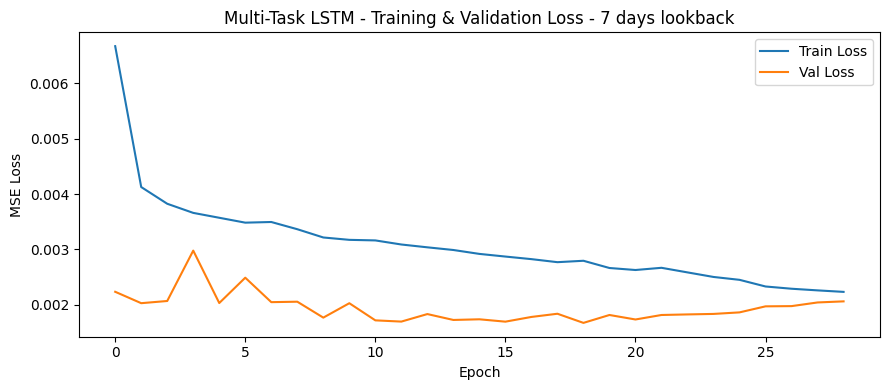

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Multi-Task LSTM - Training & Validation Loss - 7 days lookback')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
def inverse_transform_col(arr_1d, col_idx, scaler):
    dummy = np.zeros((len(arr_1d), scaler.n_features_in_))
    dummy[:, col_idx] = arr_1d
    return scaler.inverse_transform(dummy)[:, col_idx]

In [19]:
@torch.no_grad()
def predict_full_sequence(model, val_arr, test_arr, seq_len, horizon, col_indices, scaler, device):
    model.eval()
    all_preds = []
    all_trues = []
    context = np.concatenate([val_arr[-seq_len:], test_arr], axis=0)
    data_tensor = torch.tensor(context, dtype=torch.float32).to(device)
    
    for start in range(0, len(context) - seq_len - horizon + 1, horizon):
        x = data_tensor[start : start + seq_len].unsqueeze(0)
        y_true = context[start + seq_len : start + seq_len + horizon]
        
        pred = model(x).squeeze(0).cpu().numpy()
        all_preds.append(pred)
        all_trues.append(y_true[:, col_indices])

    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)
    
    preds_orig = np.zeros_like(all_preds)
    trues_orig = np.zeros_like(all_trues)
    
    for i, col_idx in enumerate(col_indices):
        preds_orig[:, i] = inverse_transform_col(all_preds[:, i], col_idx, scaler)
        trues_orig[:, i] = inverse_transform_col(all_trues[:, i], col_idx, scaler)
    
    return preds_orig, trues_orig


preds, trues = predict_full_sequence(
    model, val_arr, test_arr, SEQ_LEN, HORIZON, col_indices, fitted_scaler, DEVICE
)

print(f"Predictions shape: {preds.shape}")
print(f"True values shape: {trues.shape}")

Predictions shape: (744, 4)
True values shape: (744, 4)


In [20]:
from sklearn.metrics import r2_score

PM25        MAE: 18.3561   RMSE: 23.7644   r2: 0.6030
NO2         MAE: 5.7563   RMSE: 7.6226   r2: 0.5693
CO          MAE: 0.2133   RMSE: 0.2940   r2: 0.4902
OZONE       MAE: 7.4585   RMSE: 9.7111   r2: 0.8132


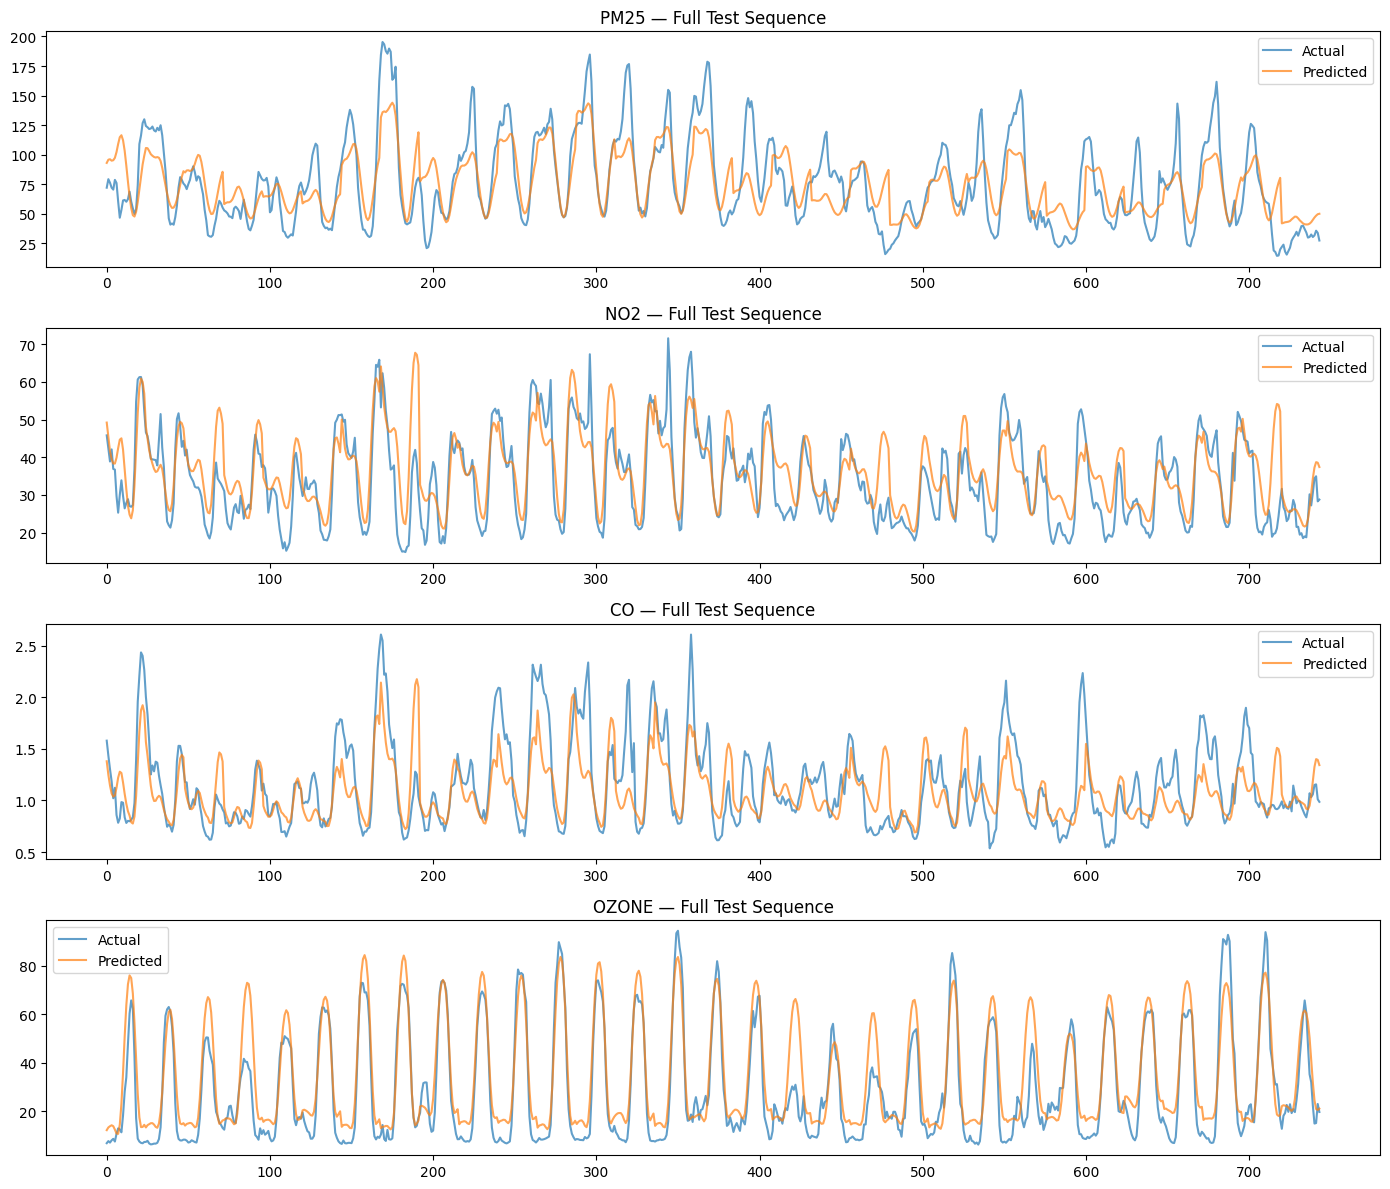

In [21]:
for i, name in enumerate(TARGETS):
    mae  = mean_absolute_error(trues[:, i], preds[:, i])
    rmse = np.sqrt(mean_squared_error(trues[:, i], preds[:, i]))
    r2 = r2_score(trues[:, i], preds[:, i])
    print(f"{name.upper():<10}  MAE: {mae:.4f}   RMSE: {rmse:.4f}   r2: {r2:.4f}")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
for i, name in enumerate(TARGETS):
    axes[i].plot(trues[:, i], label='Actual', alpha=0.7)
    axes[i].plot(preds[:, i], label='Predicted', alpha=0.7)
    axes[i].set_title(f"{name.upper()} — Full Test Sequence")
    axes[i].legend()
plt.tight_layout()
plt.show()